## Visualiserer studieområdet

Her visualiseres studieområdet for å kontrollere at bufferen rundt Oslo er riktig generert og dekker ønsket område.

In [2]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

## Definerer studieområde

For å gjennomføre analysen defineres et studieområde rundt Oslo. Dette gjøres ved å opprette et punkt og lage en buffer rundt dette punktet som representerer området vi analyserer.

In [3]:
# Oslo sentrum (koordinater)
oslo_center = Point(10.75, 59.91)

# Lage GeoDataFrame
oslo_gdf = gpd.GeoDataFrame(geometry=[oslo_center], crs="EPSG:4326")

# Konverter til meter-basert CRS før buffer
oslo_area = oslo_gdf.to_crs(epsg=3857).buffer(20000)

# Tilbake til WGS84
oslo_area = gpd.GeoDataFrame(geometry=oslo_area, crs="EPSG:3857").to_crs(epsg=4326)

oslo_area

,geometry
0,"POLYGON ((10.92966 59.91, 10.9288 59.90117, 10..."


## Visualiserer studieområdet

Her visualiseres studieområdet for å kontrollere at bufferen rundt Oslo er riktig generert og dekker ønsket område.

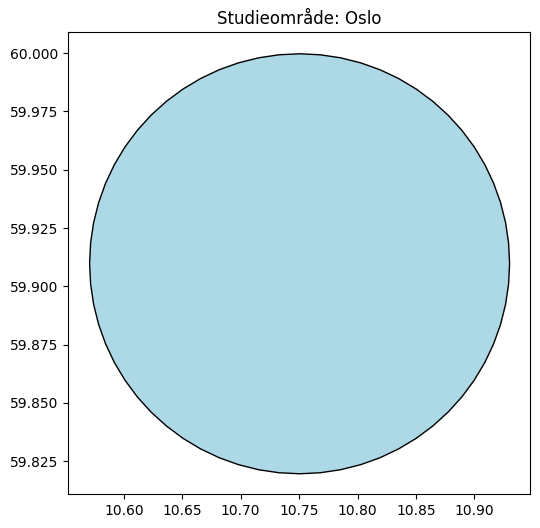

In [4]:
fig, ax = plt.subplots(figsize=(6,6))
oslo_area.plot(ax=ax, color="lightblue", edgecolor="black")
ax.set_title("Studieområde: Oslo")
plt.show()

## Genererer kritiske punkter

For å simulere kritiske samfunnsfunksjoner som skoler eller beredskapspunkter, genereres et sett med tilfeldige punkter innenfor studieområdet. Disse brukes videre i analysen for å undersøke dekning og tilgjengelighet.

In [5]:
import random

points = []

# Lag 30 tilfeldige punkter innenfor området
minx, miny, maxx, maxy = oslo_area.total_bounds

for _ in range(30):
    x = random.uniform(minx, maxx)
    y = random.uniform(miny, maxy)
    points.append(Point(x, y))

points_gdf = gpd.GeoDataFrame(geometry=points, crs="EPSG:4326")

points_gdf

,geometry
0,POINT (10.899 59.86281)
1,POINT (10.88933 59.86413)
2,POINT (10.81077 59.90479)
3,POINT (10.68876 59.97967)
4,POINT (10.87193 59.97168)
5,POINT (10.72833 59.94657)
6,POINT (10.73075 59.85523)
7,POINT (10.74277 59.82451)
8,POINT (10.78582 59.97661)
9,POINT (10.81994 59.92001)


## Visualiserer kritiske punkter

Her visualiseres de genererte punktene sammen med studieområdet for å se hvordan de er fordelt geografisk.

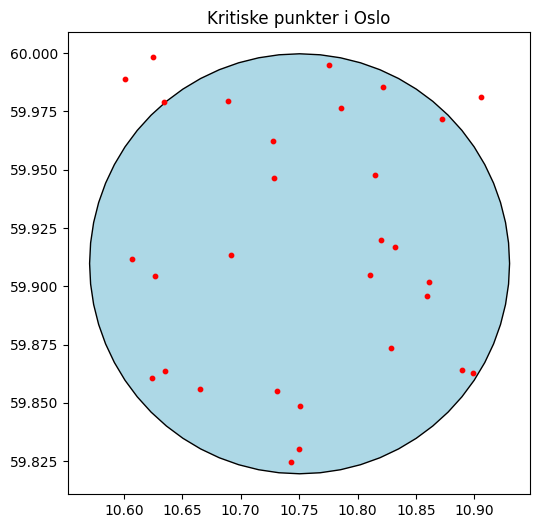

In [6]:
fig, ax = plt.subplots(figsize=(6,6))
oslo_area.plot(ax=ax, color="lightblue", edgecolor="black")
points_gdf.plot(ax=ax, color="red", markersize=10)

ax.set_title("Kritiske punkter i Oslo")
plt.show()

## Bufferanalyse

For å analysere tilgjengelighet til kritiske funksjoner, opprettes det en buffersone rundt hvert punkt. Dette representerer et område som kan nås innenfor en viss avstand.

In [7]:
# Konverter til meter-basert CRS
points_proj = points_gdf.to_crs(epsg=3857)

# Lag buffer (1000 meter)
buffer = points_proj.buffer(1000)

# Tilbake til WGS84
buffer_gdf = gpd.GeoDataFrame(geometry=buffer, crs="EPSG:3857").to_crs(epsg=4326)

buffer_gdf

,geometry
0,"POLYGON ((10.90798 59.86281, 10.90794 59.86237..."
1,"POLYGON ((10.89831 59.86413, 10.89827 59.86369..."
2,"POLYGON ((10.81975 59.90479, 10.81971 59.90435..."
3,"POLYGON ((10.69774 59.97967, 10.6977 59.97923,..."
4,"POLYGON ((10.88092 59.97168, 10.88087 59.97124..."
5,"POLYGON ((10.73731 59.94657, 10.73727 59.94613..."
6,"POLYGON ((10.73973 59.85523, 10.73969 59.85479..."
7,"POLYGON ((10.75176 59.82451, 10.75171 59.82407..."
8,"POLYGON ((10.7948 59.97661, 10.79476 59.97616,..."
9,"POLYGON ((10.82892 59.92001, 10.82888 59.91957..."


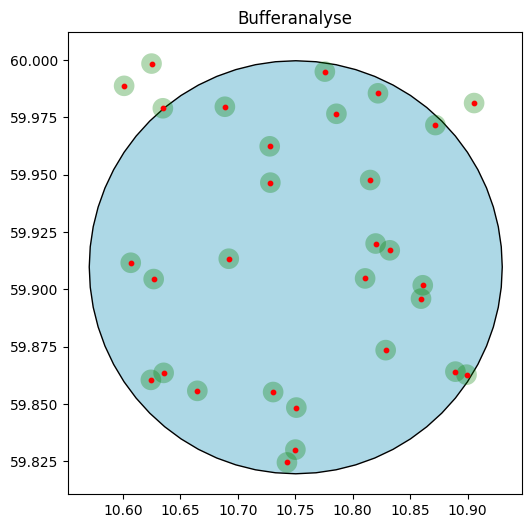

In [8]:
fig, ax = plt.subplots(figsize=(6,6))
oslo_area.plot(ax=ax, color="lightblue", edgecolor="black")
buffer_gdf.plot(ax=ax, color="green", alpha=0.3)
points_gdf.plot(ax=ax, color="red", markersize=10)

ax.set_title("Bufferanalyse")
plt.show()

## Overlay-analyse

For å undersøke hvilke områder som dekkes av buffersonene, utføres en overlay-operasjon. Her brukes en intersection mellom studieområdet og buffersonene for å identifisere overlappende områder.

In [9]:
# Overlay (intersection)
overlay = gpd.overlay(oslo_area, buffer_gdf, how="intersection")

overlay

,geometry
0,"POLYGON ((10.89938 59.85992, 10.89714 59.8584,..."
1,"POLYGON ((10.89827 59.86369, 10.89814 59.86326..."
2,"POLYGON ((10.81971 59.90435, 10.81958 59.90391..."
3,"POLYGON ((10.6977 59.97923, 10.69757 59.9788, ..."
4,"POLYGON ((10.87704 59.97363, 10.8809 59.9715, ..."
5,"POLYGON ((10.73727 59.94613, 10.73714 59.94569..."
6,"POLYGON ((10.73969 59.85479, 10.73956 59.85435..."
7,"POLYGON ((10.75171 59.82407, 10.75158 59.82363..."
8,"POLYGON ((10.79476 59.97616, 10.79463 59.97573..."
9,"POLYGON ((10.82888 59.91957, 10.82875 59.91913..."


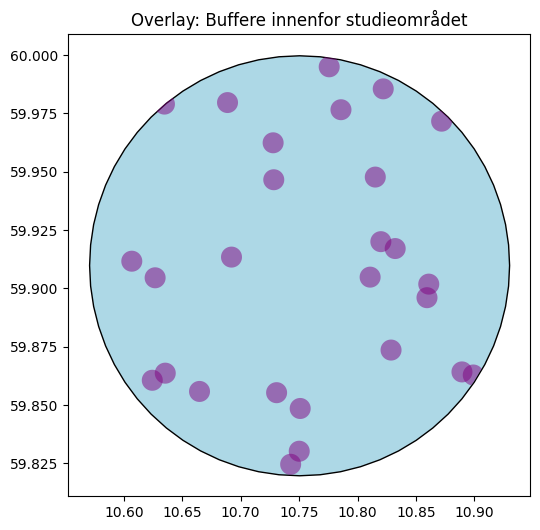

In [10]:
fig, ax = plt.subplots(figsize=(6,6))

oslo_area.plot(ax=ax, color="lightblue", edgecolor="black")
overlay.plot(ax=ax, color="purple", alpha=0.5)

ax.set_title("Overlay: Buffere innenfor studieområdet")
plt.show()

## Romlig aggregering

For å få en oversikt over hvor mange kritiske punkter som finnes i studieområdet, utføres en romlig aggregering. Her telles antall punkter innenfor området.

In [11]:
# Spatial join (punkter innenfor området)
joined = gpd.sjoin(points_gdf, oslo_area, predicate="within")

# Tell antall
count = len(joined)

print("Antall kritiske punkter innenfor området:", count)

Antall kritiske punkter innenfor området: 26


In [12]:
joined.head()

,geometry,index_right
0,POINT (10.899 59.86281),0
1,POINT (10.88933 59.86413),0
2,POINT (10.81077 59.90479),0
3,POINT (10.68876 59.97967),0
4,POINT (10.87193 59.97168),0


## Bruk av Pandas

Pandas brukes her for enkel tabellbasert analyse av resultatene fra den romlige aggregeringen.

In [13]:
df = pd.DataFrame(joined.drop(columns="geometry"))
df.head()

,index_right
0,0
1,0
2,0
3,0
4,0


## Rasteranalyse (DEM og helning)

For å analysere terreng ble høydedata (Digital Elevation Model - DEM) brukt.

Følgende steg ble gjennomført:

1. Nedlasting av høydedata fra Kartverket
2. Generering av helningskart (slope) basert på DEM
3. Filtrering av områder med høy helning (over 30 grader)
4. Konvertering av raster til vektordata (polygonize)
5. Generering av hillshade for visualisering av terreng

Eksempel på kommandoer brukt:

gdal_dem slope input.tif slope.tif

gdal_calc.py -A slope.tif --calc="A>30" --outfile=steep.tif

gdal_polygonize.py steep.tif output.shp

gdal_hillshade input.tif hillshade1.tif

gdal_hillshade -az 315 -alt 45 input.tif hillshade2.tif

Denne analysen er relevant i et totalforsvarsperspektiv fordi områder med høy helning kan være vanskelig tilgjengelige i en krisesituasjon.